# Expérience

In [1]:
import os

from vote_simulation.simulation.simulation import simulation_series_from_config

print(os.getcwd())


results = simulation_series_from_config("config.toml", reload=True, compute_metrics=True)

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/demo/rolland-al_sim


Running simulation series: 100%|██████████| 12/12 [02:34<00:00, 12.90s/it]

Completed 12 simulation series.


## Résultats
### Matrix of metric

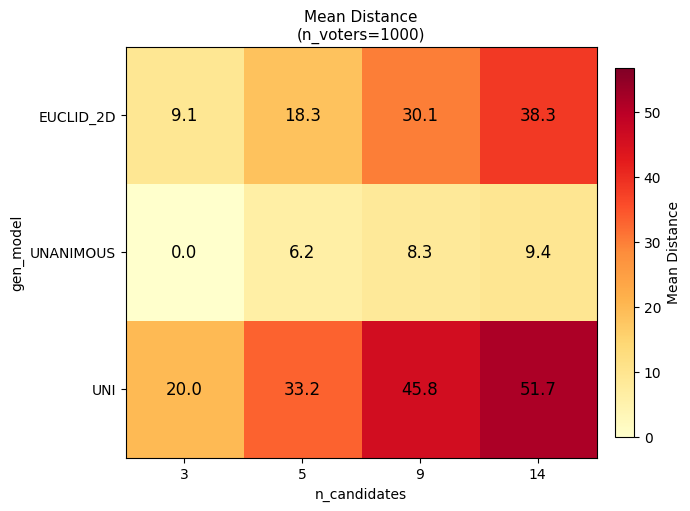

<Axes: title={'center': 'Mean Distance\n(n_voters=1000)'}, xlabel='n_candidates', ylabel='gen_model'>

In [2]:
results.plot_metric_heatmap(row_param="gen_model", col_param="n_candidates")

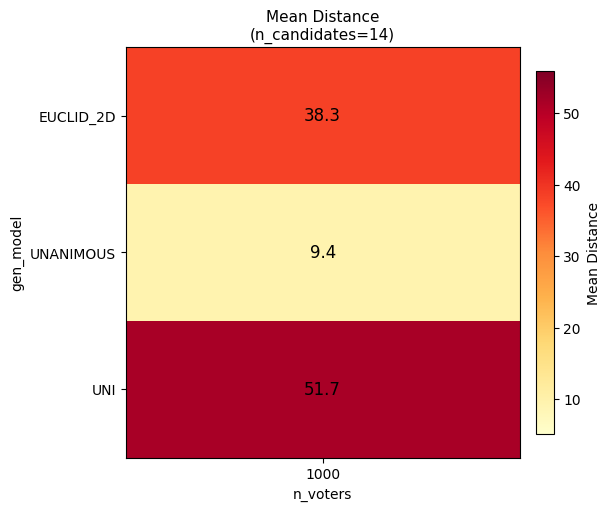

<Axes: title={'center': 'Mean Distance\n(n_candidates=14)'}, xlabel='n_voters', ylabel='gen_model'>

In [3]:
results.filter(n_candidates=14).plot_metric_heatmap(row_param="gen_model", col_param="n_voters")

## Metrics
### Summary 

In [4]:
df = results.summary_frame()
print(df.to_string(index=False))

gen_model  n_voters  n_candidates  step_count  n_iterations  mean_distance most_distant_rule_a most_distant_rule_b  most_distant_distance
EUCLID_2D      1000             3        1000          1000       9.137083              BUCK_R                PLU1              31.850000
EUCLID_2D      1000             5        1000          1000      18.325000              BUCK_R                PLU1              60.450001
EUCLID_2D      1000             9        1000          1000      30.075140                BORD                PLU1              82.050003
EUCLID_2D      1000            14        1000          1000      38.279443                BORD                PLU1              92.099998
UNANIMOUS      1000             3        1000          1000       0.000000                  RV                  RV               0.000000
UNANIMOUS      1000             5        1000          1000       6.250000                  RV                AP_T              50.000000
UNANIMOUS      1000             9 

## Rule pair distance
`rule_pair_frame()` extracts the mean distance between two specific rules across all series:



In [5]:
df = results.rule_pair_frame("PLU1", "BORD")
print(df.to_string(index=False))

gen_model  n_voters  n_candidates  distance
EUCLID_2D      1000             3 30.400000
EUCLID_2D      1000             5 57.400002
EUCLID_2D      1000             9 82.050003
EUCLID_2D      1000            14 92.099998
UNANIMOUS      1000             3  0.000000
UNANIMOUS      1000             5  0.000000
UNANIMOUS      1000             9  0.000000
UNANIMOUS      1000            14  0.000000
      UNI      1000             3 24.000000
      UNI      1000             5 44.033333
      UNI      1000             9 66.675003
      UNI      1000            14 75.333336


## Rule pair heatmap 
Focus single pair 

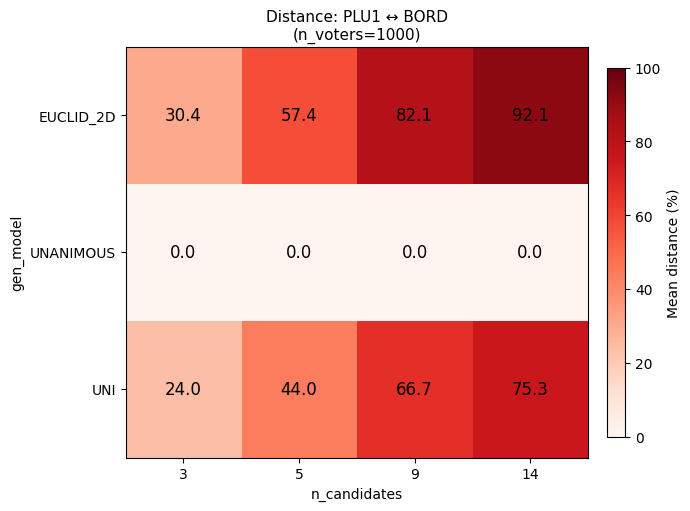

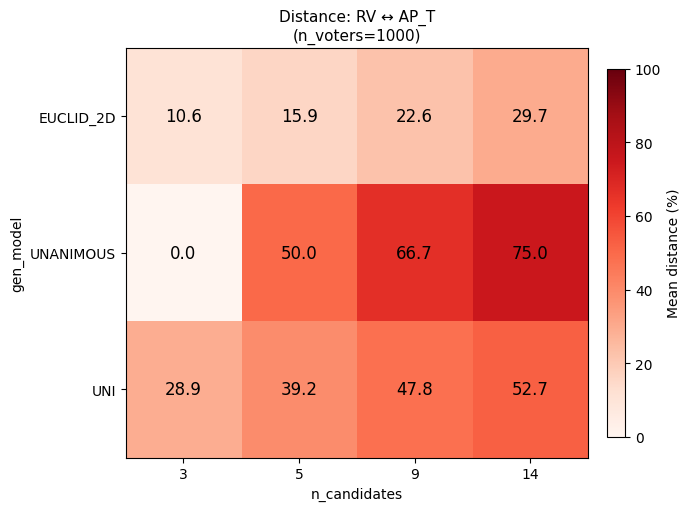

<Axes: title={'center': 'Distance: RV ↔ AP_T\n(n_voters=1000)'}, xlabel='n_candidates', ylabel='gen_model'>

In [7]:
results.filter(n_voters=1000).plot_rule_pair_heatmap(
    "PLU1", "BORD",
    row_param="gen_model",
    col_param="n_candidates",
    show=True,
)

results.plot_rule_pair_heatmap(
    "RV", "AP_T",
    row_param="gen_model",
    col_param="n_candidates",
    show=True,
)

## Comparison 

In [8]:
summary = results.summary_frame()
print(summary)


    gen_model  n_voters  n_candidates  step_count  n_iterations  \
0   EUCLID_2D      1000             3        1000          1000   
1   EUCLID_2D      1000             5        1000          1000   
2   EUCLID_2D      1000             9        1000          1000   
3   EUCLID_2D      1000            14        1000          1000   
4   UNANIMOUS      1000             3        1000          1000   
5   UNANIMOUS      1000             5        1000          1000   
6   UNANIMOUS      1000             9        1000          1000   
7   UNANIMOUS      1000            14        1000          1000   
8         UNI      1000             3        1000          1000   
9         UNI      1000             5        1000          1000   
10        UNI      1000             9        1000          1000   
11        UNI      1000            14        1000          1000   

    mean_distance most_distant_rule_a most_distant_rule_b  \
0        9.137083              BUCK_R                PLU1   
1     

## Elected caracteristics

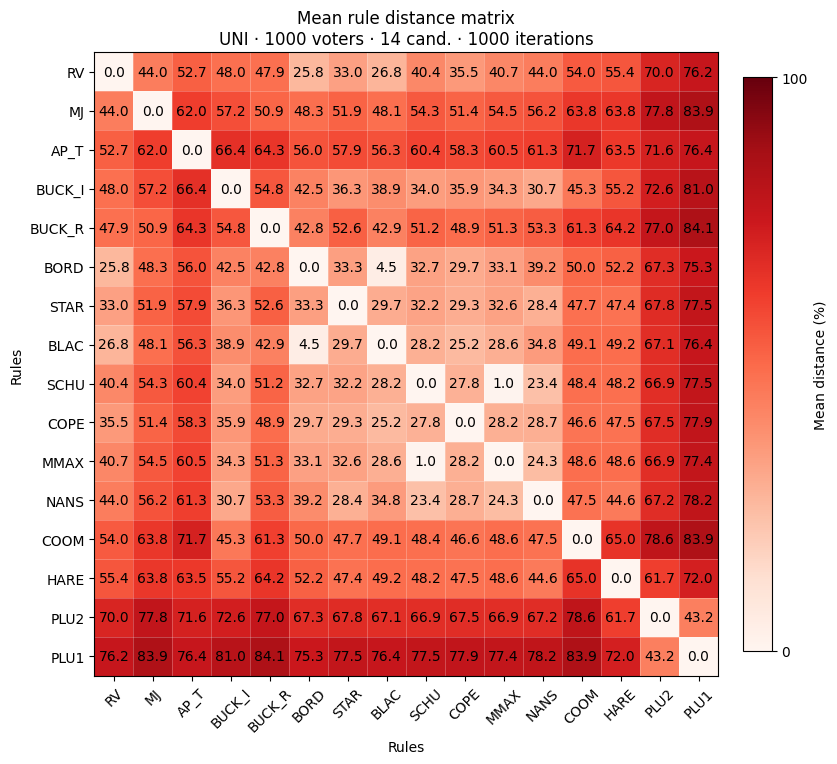

 social_acceptability_mean  social_acceptability_std  utility_mean_mean  utility_mean_std  utility_median_mean  utility_median_std  utility_var_mean  utility_var_std  rank_mean_mean  rank_mean_std  rank_median_mean  rank_median_std  rank_var_mean  rank_var_std  freq_first_mean  freq_first_std  freq_last_mean  freq_last_std  has_tie_mean  has_tie_std  n_cowinners_mean  n_cowinners_std
                  0.523613                  0.013254           0.515405          0.004985             0.523404            0.010885          0.083186         0.002286        7.282211       0.068938            7.0120         0.104192      16.206333      0.446028         0.077693        0.008371        0.065334       0.007853         0.001     0.031607             1.001         0.031607
                  0.531197                  0.058733           0.512215          0.006731             0.518175            0.013203          0.084799         0.002206        7.327159       0.093517            7.0725         0.2

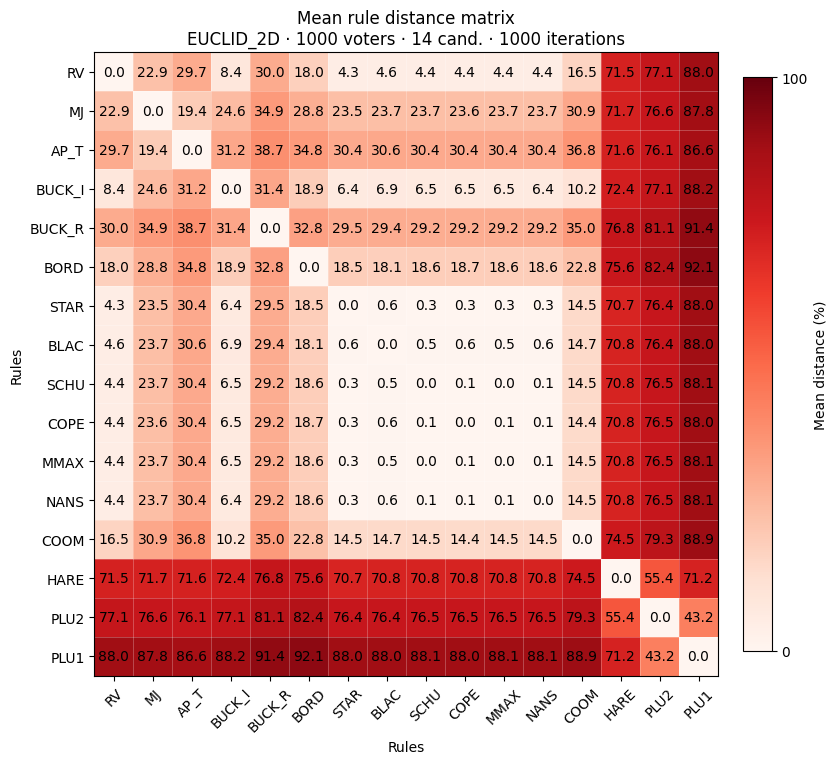

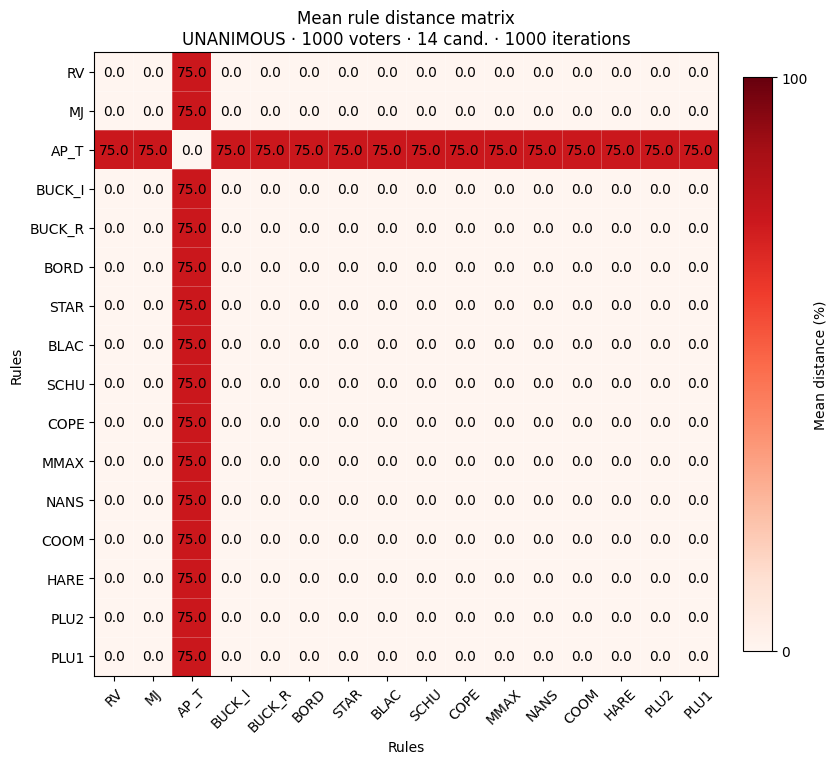

<Axes: title={'center': 'Mean rule distance matrix\nUNANIMOUS · 1000 voters · 14 cand. · 1000 iterations'}, xlabel='Rules', ylabel='Rules'>

In [9]:
series = results.get_series(n_candidates=14, gen_model="UNI", n_voters=1000)

series.plot_mean_distance_matrix()

df = series.metrics_summary_frame

print(df.to_string(index=False))

series = results.get_series(n_candidates=14, gen_model="EUCLID_2D", n_voters=1000)
series.plot_mean_distance_matrix()

series = results.get_series(n_candidates=14, gen_model="UNANIMOUS", n_voters=1000)
series.plot_mean_distance_matrix()





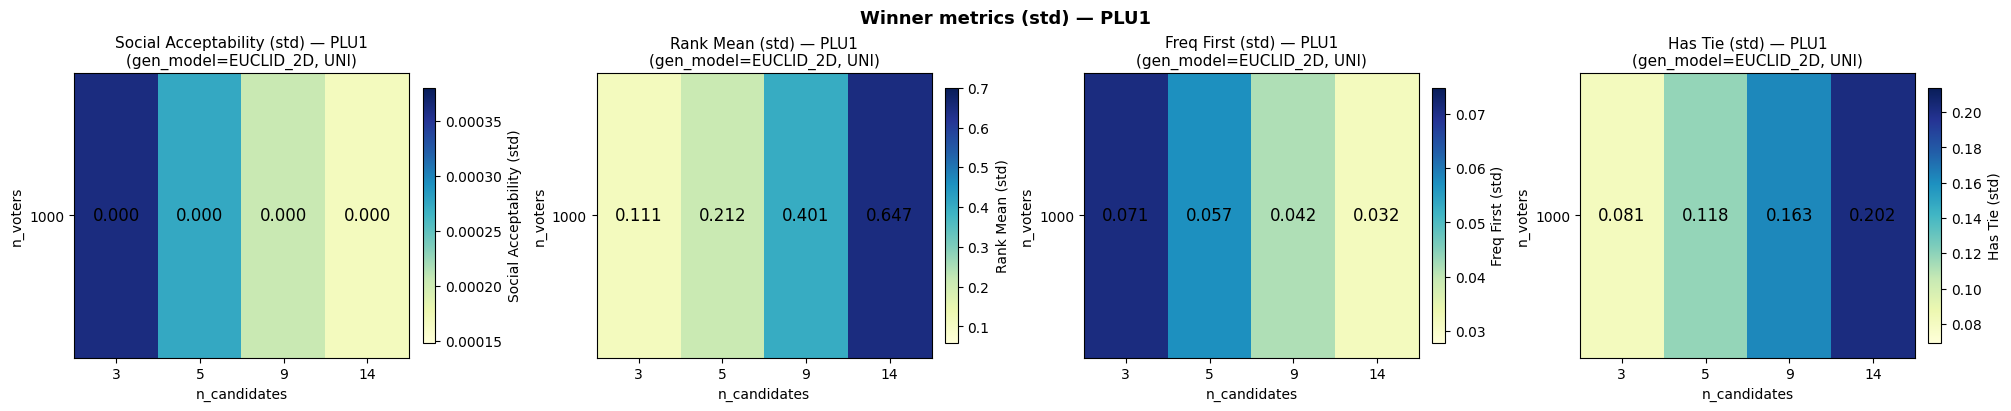

array([<Axes: title={'center': 'Social Acceptability (std) — PLU1\n(gen_model=EUCLID_2D, UNI)'}, xlabel='n_candidates', ylabel='n_voters'>,
       <Axes: title={'center': 'Rank Mean (std) — PLU1\n(gen_model=EUCLID_2D, UNI)'}, xlabel='n_candidates', ylabel='n_voters'>,
       <Axes: title={'center': 'Freq First (std) — PLU1\n(gen_model=EUCLID_2D, UNI)'}, xlabel='n_candidates', ylabel='n_voters'>,
       <Axes: title={'center': 'Has Tie (std) — PLU1\n(gen_model=EUCLID_2D, UNI)'}, xlabel='n_candidates', ylabel='n_voters'>],
      dtype=object)

In [18]:
results.plot_winner_metrics_grid(
    "PLU1",
    metrics=["social_acceptability", "rank_mean", "freq_first", "has_tie"],
    stat="std",
)

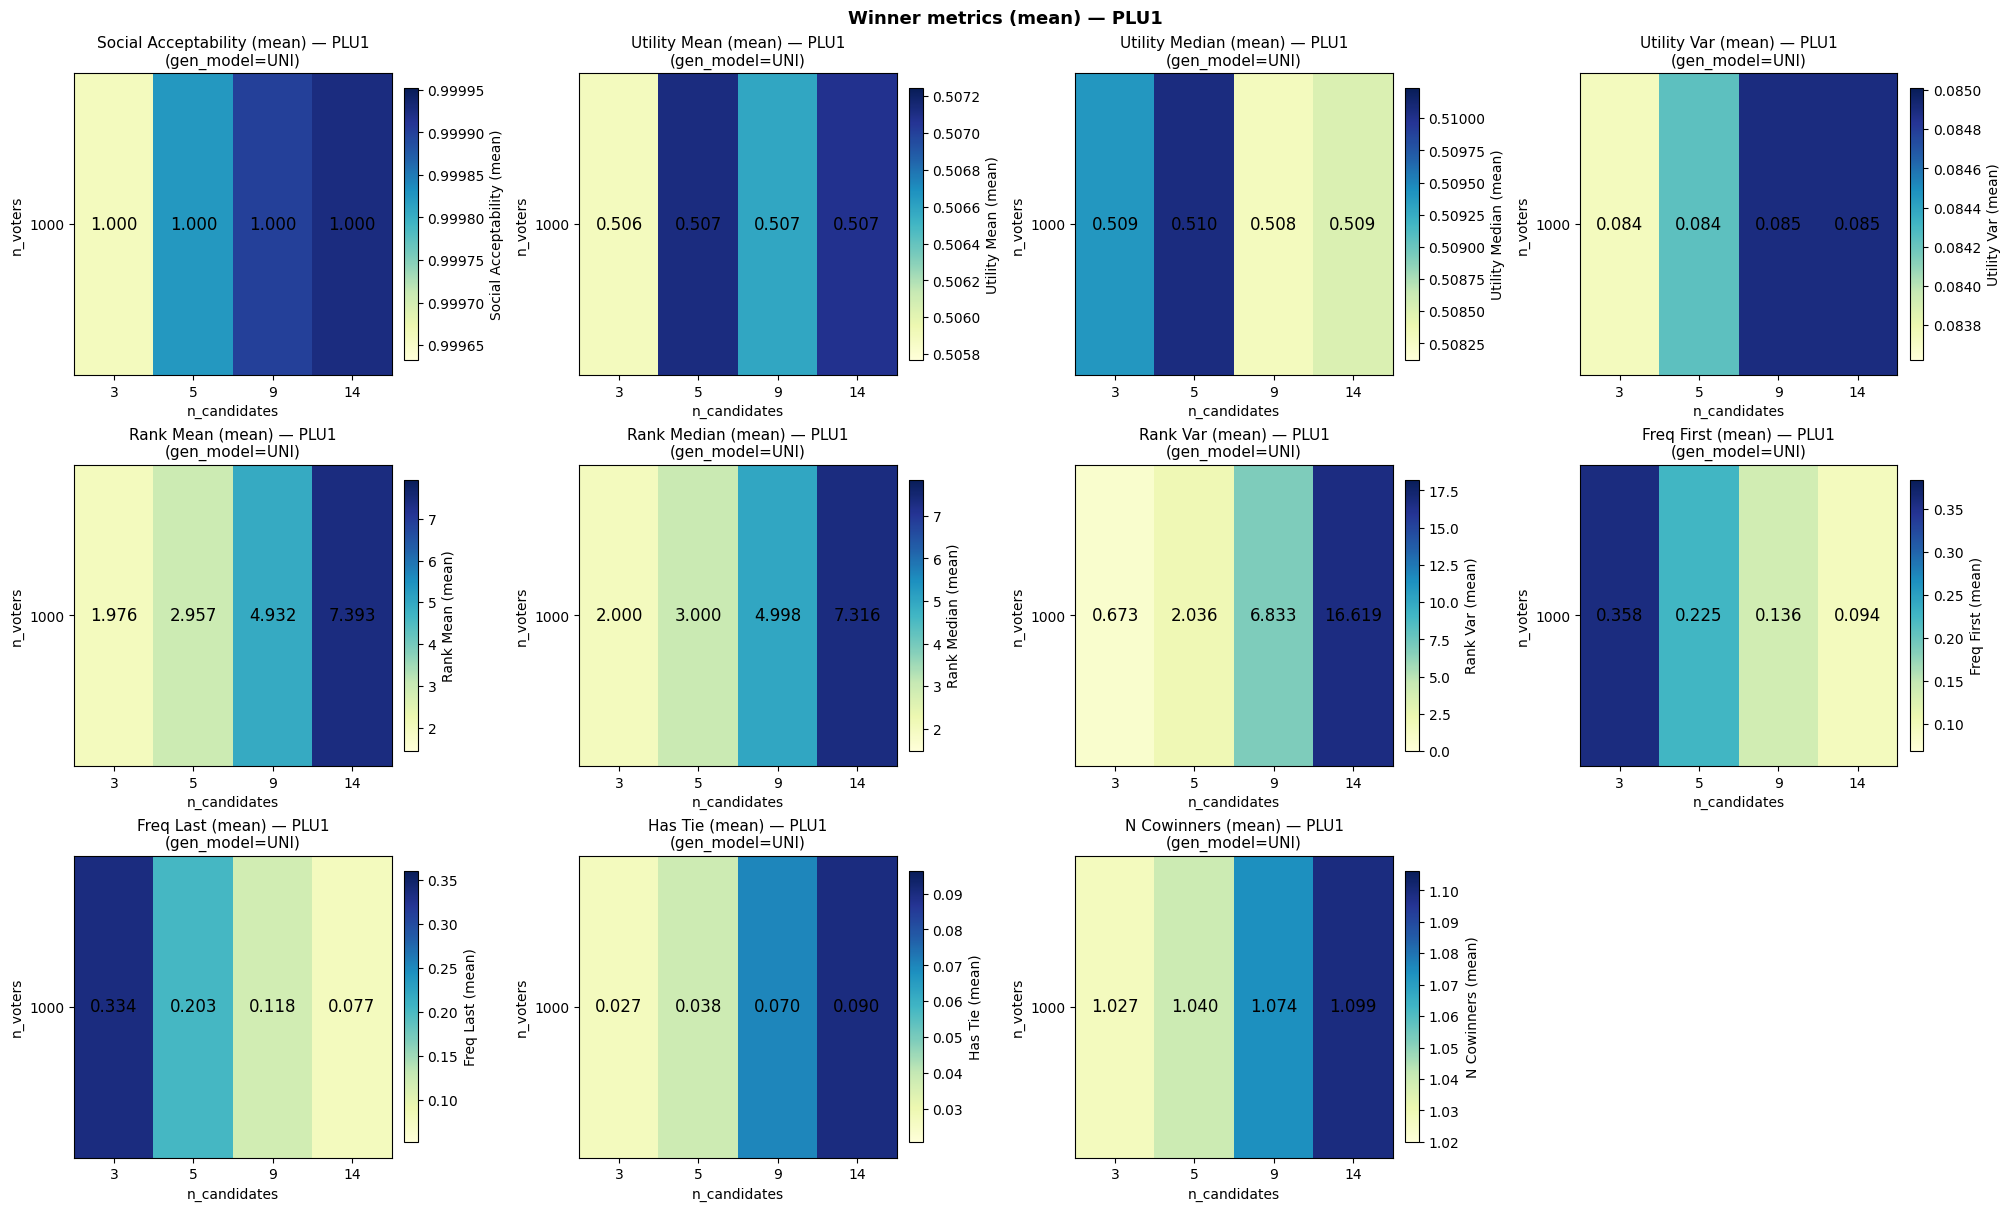

array([[<Axes: title={'center': 'Social Acceptability (mean) — PLU1\n(gen_model=UNI)'}, xlabel='n_candidates', ylabel='n_voters'>,
        <Axes: title={'center': 'Utility Mean (mean) — PLU1\n(gen_model=UNI)'}, xlabel='n_candidates', ylabel='n_voters'>,
        <Axes: title={'center': 'Utility Median (mean) — PLU1\n(gen_model=UNI)'}, xlabel='n_candidates', ylabel='n_voters'>,
        <Axes: title={'center': 'Utility Var (mean) — PLU1\n(gen_model=UNI)'}, xlabel='n_candidates', ylabel='n_voters'>],
       [<Axes: title={'center': 'Rank Mean (mean) — PLU1\n(gen_model=UNI)'}, xlabel='n_candidates', ylabel='n_voters'>,
        <Axes: title={'center': 'Rank Median (mean) — PLU1\n(gen_model=UNI)'}, xlabel='n_candidates', ylabel='n_voters'>,
        <Axes: title={'center': 'Rank Var (mean) — PLU1\n(gen_model=UNI)'}, xlabel='n_candidates', ylabel='n_voters'>,
        <Axes: title={'center': 'Freq First (mean) — PLU1\n(gen_model=UNI)'}, xlabel='n_candidates', ylabel='n_voters'>],
       [<Axes: 

In [19]:
results.filter(gen_model="UNI").plot_winner_metrics_grid(
    "PLU1",
    row_param="n_voters", col_param="n_candidates",
    save_path="results/all_metrics_plu1.png",
)


## Metrics matrix

Matrice règles × métriques : chaque ligne est une métrique, chaque colonne une règle.  
Le dégradé est normailsé par métrique pour que les règles soient comparables.  

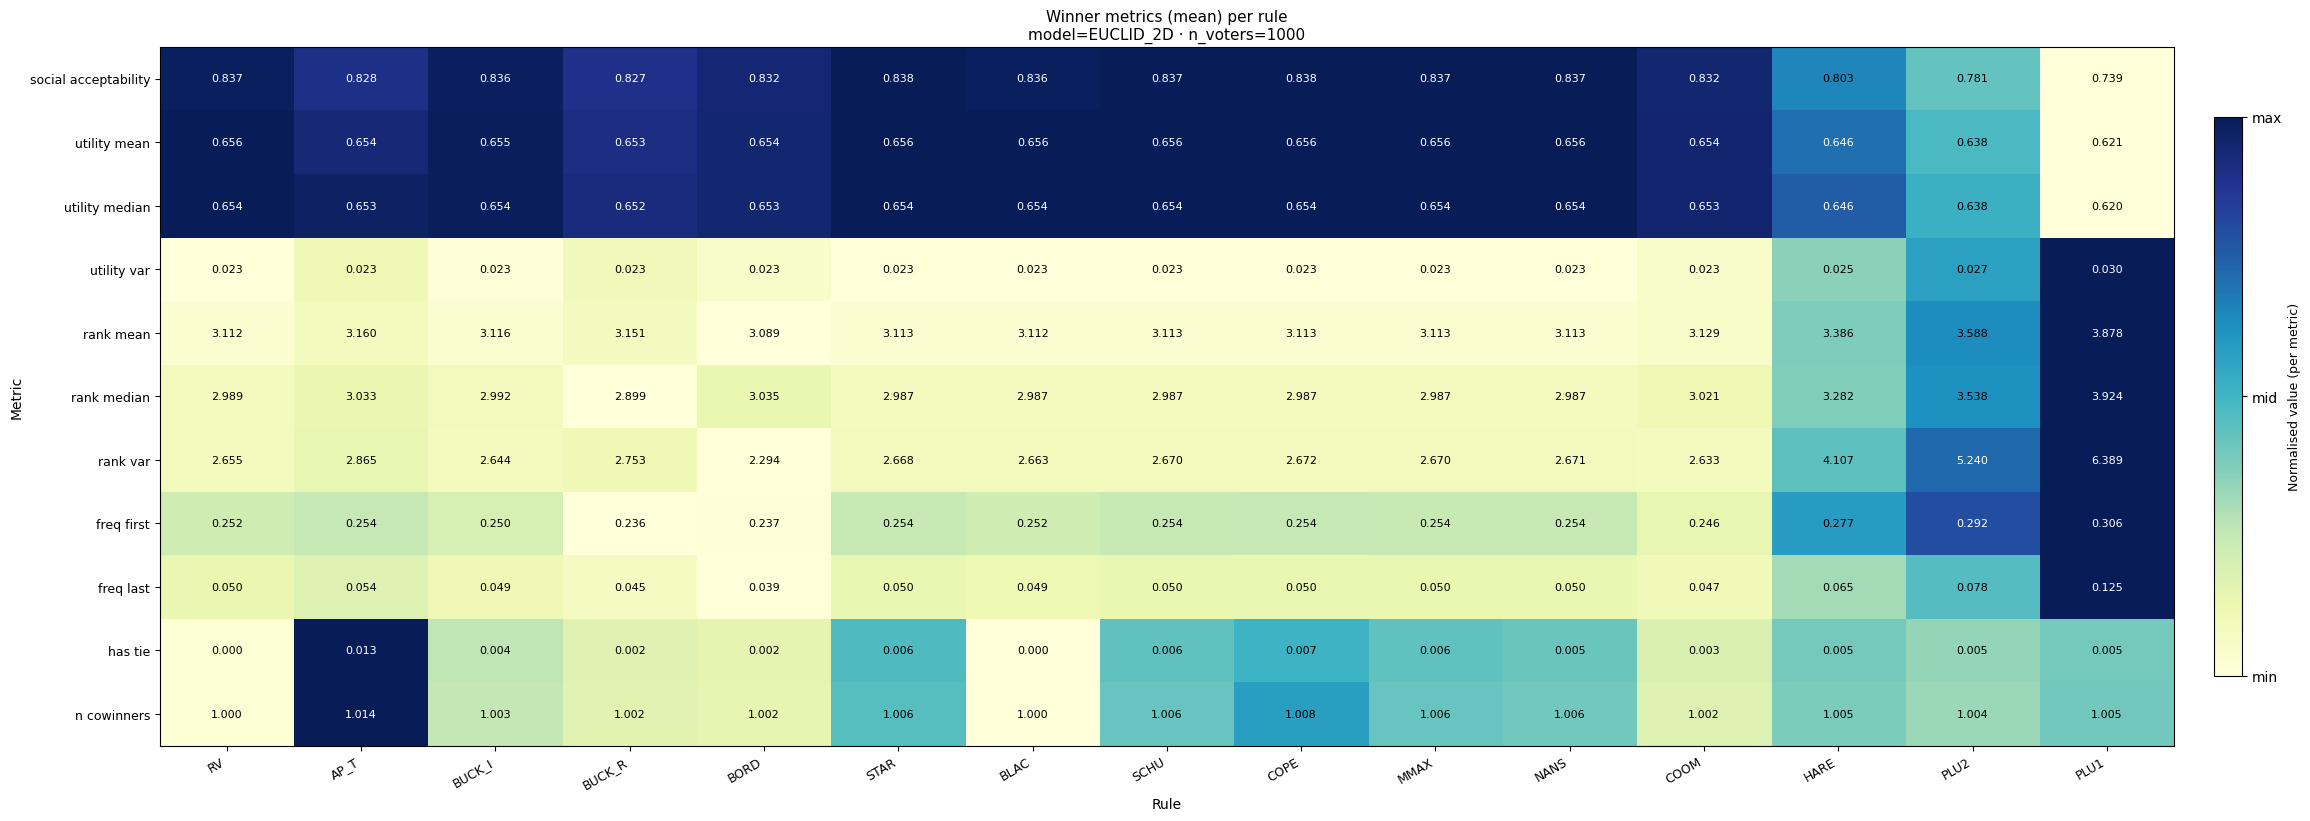

<Axes: title={'center': 'Winner metrics (mean) per rule\nmodel=EUCLID_2D · n_voters=1000'}, xlabel='Rule', ylabel='Metric'>

In [11]:
results.filter(gen_model="EUCLID_2D").plot_metrics_rules_matrix(stat="mean", save_path="results/metrics_rules_matrix.png")

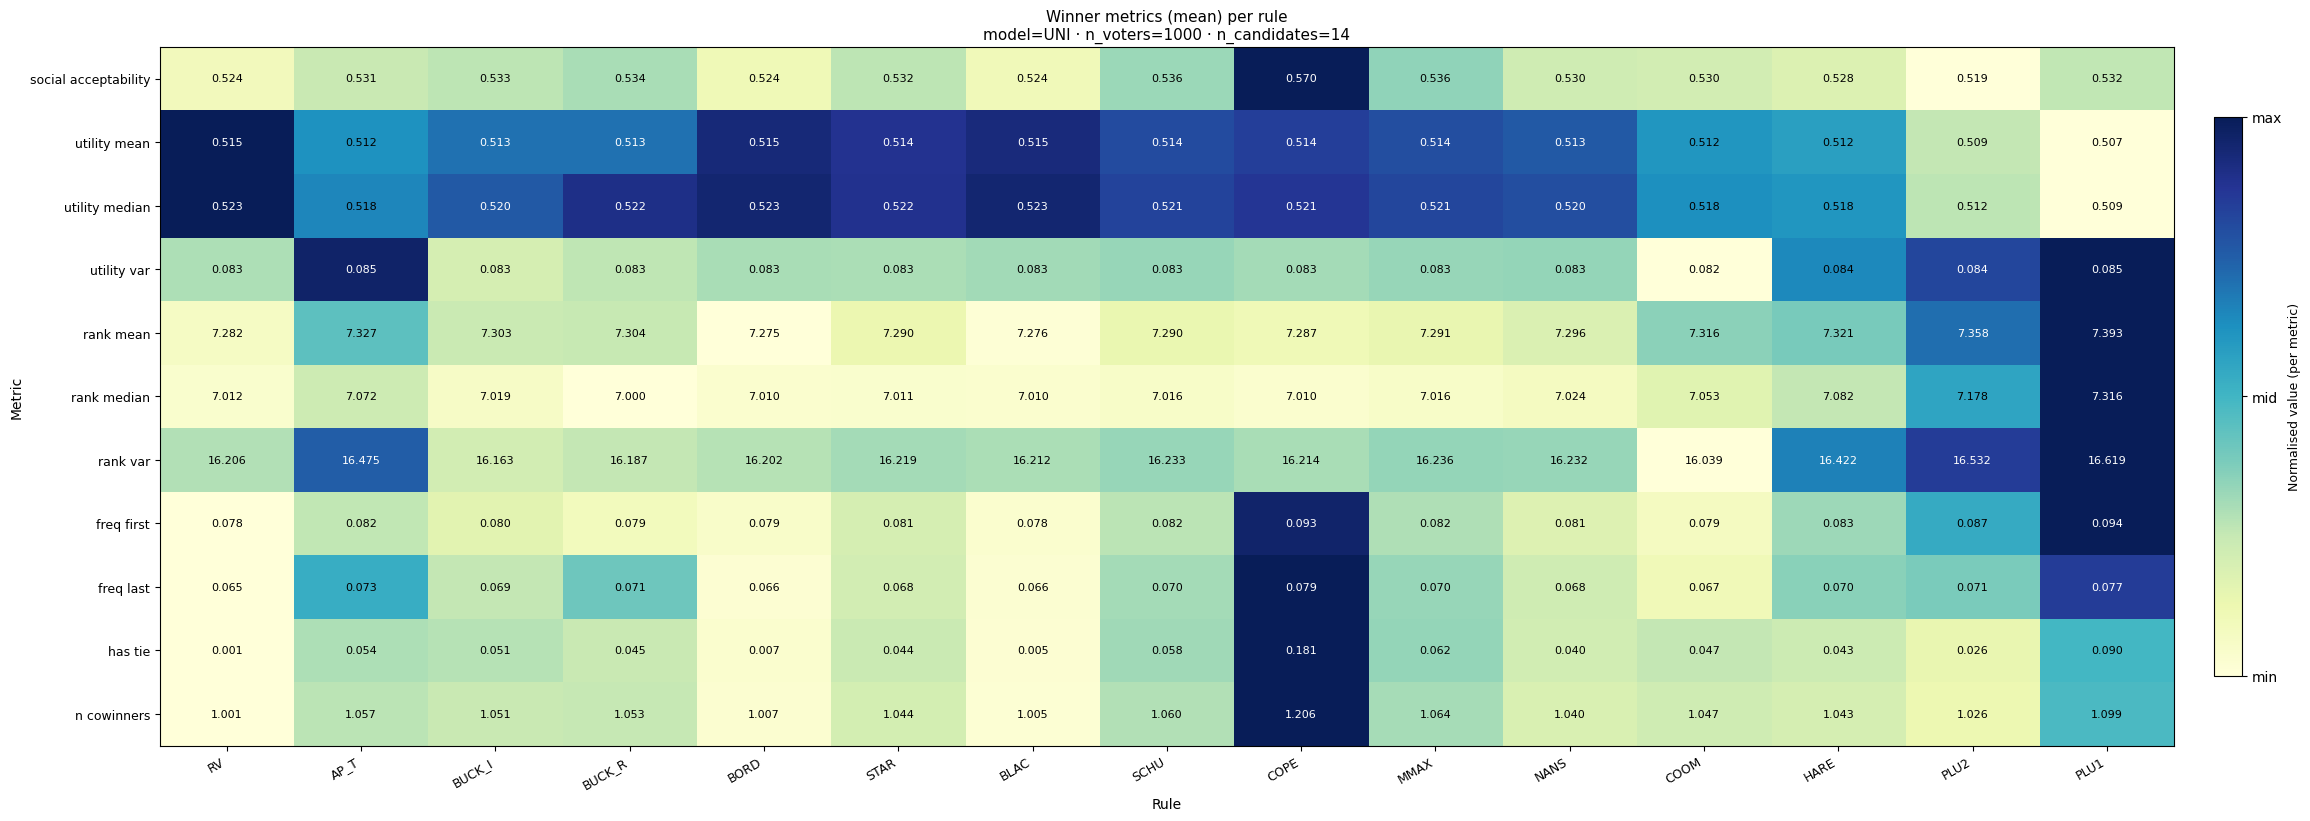

<Axes: title={'center': 'Winner metrics (mean) per rule\nmodel=UNI · n_voters=1000 · n_candidates=14'}, xlabel='Rule', ylabel='Metric'>

In [12]:
# Filtré sur un modèle et un nombre de candidats spécifique
results.filter(gen_model="UNI", n_candidates=14).plot_metrics_rules_matrix(
    stat="mean",
    save_path="results/metrics_rules_matrix_UNI_c14.png",
)

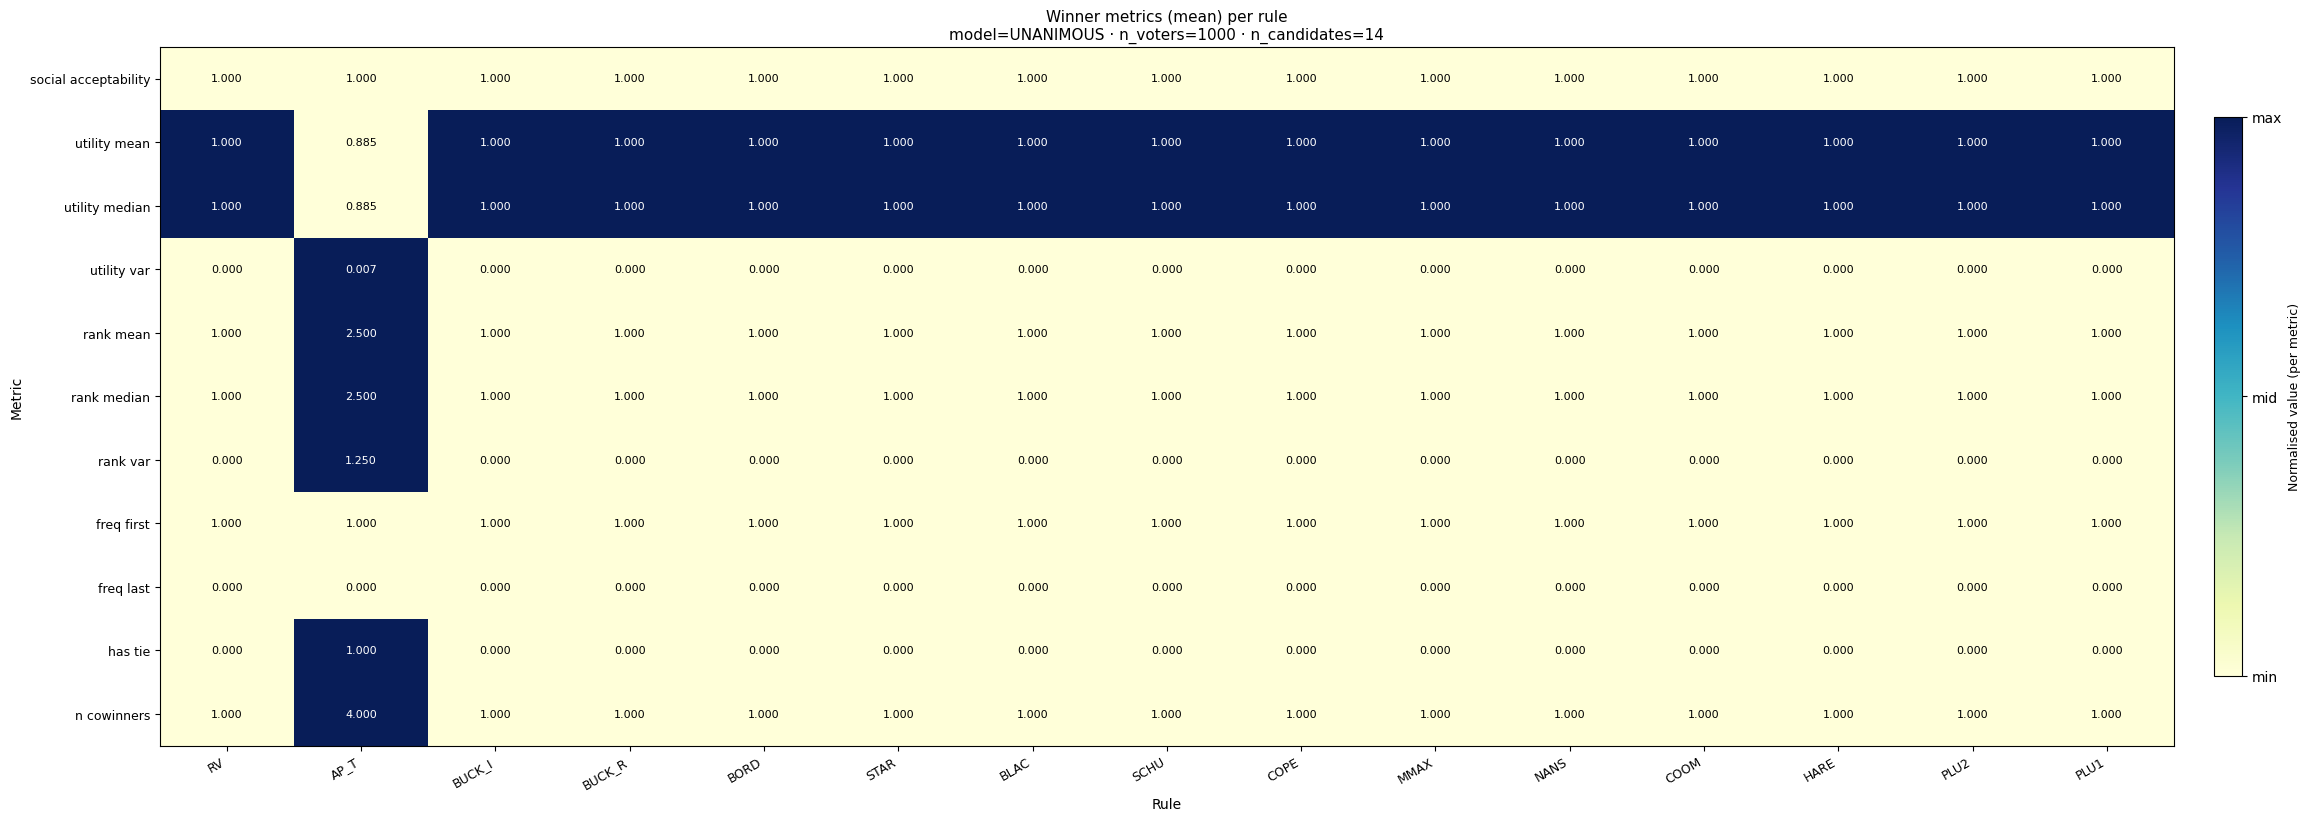

<Axes: title={'center': 'Winner metrics (mean) per rule\nmodel=UNANIMOUS · n_voters=1000 · n_candidates=14'}, xlabel='Rule', ylabel='Metric'>

In [ ]:
# Filtré sur un modèle et un nombre de candidats spécifique
results.filter(gen_model="UNANIMOUS", n_candidates=14).plot_metrics_rules_matrix(
    stat="mean",
    save_path="results/metrics_rules_matrix_UNANIMOUS_c14.png",
)